# UPI Transaction Analysis — Full Exploratory Data Analysis + Statistical Testing

In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ════════════════════════════════════════════════════════════════
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sqlalchemy import create_engine, text
import getpass
from urllib.parse import quote_plus
import scipy
from scipy import stats
from urllib.parse import quote_plus
from scipy.stats import (ttest_ind, f_oneway, chi2_contingency,
                         pearsonr, spearmanr, mannwhitneyu)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

C = dict(blue='#3B82F6', green='#10B981', red='#EF4444', orange='#F59E0B',
         purple='#8B5CF6', teal='#14B8A6', pink='#EC4899', dark='#1E293B',
         bg='#F8FAFC', gray='#6B7280')

# Single output directory used consistently across every cell below
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports complete")

Imports complete


In [5]:
print("\n=== Running Analysis ===")
db_pass = getpass.getpass("Enter MySQL password for root@localhost: ")

DB_CONFIG = {
    "user": "root",
    "password": db_pass,
    "host": "localhost",
    "port": 3306,
    "database": "upi_transactions",
}

encoded_password = quote_plus(DB_CONFIG["password"])
connection_string = f"mysql+pymysql://{DB_CONFIG['user']}:{encoded_password}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(connection_string)


=== Running Analysis ===


Enter MySQL password for root@localhost:  ········


In [20]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — LOAD DATA
# ════════════════════════════════════════════════════════════════
customer_master = pd.read_sql_query("SELECT * FROM customer_master", engine)
device_info = pd.read_sql_query("SELECT * FROM device_info", engine)
upi_account_details = pd.read_sql_query("SELECT * FROM upi_account_details", engine)
merchant_info = pd.read_sql_query("SELECT * FROM merchant_info", engine)
upi_transaction = pd.read_sql_query("SELECT * FROM upi_transaction_history", engine)
feedback = pd.read_sql_query("SELECT * FROM customer_feedback_surveys", engine)
fraud_alert = pd.read_sql_query("SELECT * FROM fraud_alert_history", engine)

# ─── Clean ─────────────────────────────────────────

# ---- Missing value check (should already be clean per Module 2/3 validation) ----
print("Missing values in upi_transaction_history:")
print(upi_transaction.isnull().sum()[txn.isnull().sum() > 0])
print("\n(merchant_id and failure_reason nulls are EXPECTED)")


upi_transaction['amount']         = pd.to_numeric(upi_transaction['amount'], errors='coerce')
upi_transaction['fraud_flag']     = upi_transaction['fraud_flag'].astype(str).str.upper() == 'TRUE'
upi_transaction['reversal_flag']  = upi_transaction['reversal_flag'].astype(str).str.upper() == 'TRUE'
device_info['is_rooted']      = device_info['is_rooted'].astype(str).str.upper() == 'TRUE'
fraud_alert['resolved']       = fraud_alert['resolved'].astype(str).str.upper() == 'TRUE'
feedback['resolved']          = feedback['resolved'].astype(str).str.upper() == 'TRUE'

print("Tables loaded & cleaned")
for name, df in [('customer_master', customer_master), ('upi_transaction', upi_transaction),
                  ('upi_account_details', upi_account_details), ('device_info', device_info),
                  ('merchant_info', merchant_info), ('fraud_alert', fraud_alert),
                  ('feedback', feedback)]:
    print(f"  {name:<25}: {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols")

Missing values in upi_transaction_history:
merchant_id       69851
failure_reason    94129
dtype: int64

(merchant_id and failure_reason nulls are EXPECTED)
Tables loaded & cleaned
  customer_master          :  10,000 rows  x   9 cols
  upi_transaction          : 100,000 rows  x  15 cols
  upi_account_details      :  12,000 rows  x   6 cols
  device_info              :  12,000 rows  x   6 cols
  merchant_info            :     500 rows  x   6 cols
  fraud_alert              :   2,000 rows  x   7 cols
  feedback                 :   4,000 rows  x   7 cols


In [19]:
# ---- Missing value check (should already be clean per Module 2/3 validation) ----
print("Missing values in upi_transaction_history:")
print(upi_transaction.isnull().sum()[txn.isnull().sum() > 0])
print("\n(merchant_id and failure_reason nulls are EXPECTED)")

Missing values in upi_transaction_history:
merchant_id       69851
failure_reason    94129
dtype: int64

(merchant_id and failure_reason nulls are EXPECTED)


In [15]:
# ─── Clean ─────────────────────────────────────────
upi_transaction['amount']         = pd.to_numeric(upi_transaction['amount'], errors='coerce')
upi_transaction['fraud_flag']     = upi_transaction['fraud_flag'].astype(str).str.upper() == 'TRUE'
upi_transaction['reversal_flag']  = upi_transaction['reversal_flag'].astype(str).str.upper() == 'TRUE'
device_info['is_rooted']      = device_info['is_rooted'].astype(str).str.upper() == 'TRUE'
fraud_alert['resolved']       = fraud_alert['resolved'].astype(str).str.upper() == 'TRUE'
feedback['resolved']          = feedback['resolved'].astype(str).str.upper() == 'TRUE'

print("Tables loaded & cleaned")
for name, df in [('customer_master', customer_master), ('upi_transaction', upi_transaction),
                  ('upi_account_details', upi_account_details), ('device_info', device_info),
                  ('merchant_info', merchant_info), ('fraud_alert', fraud_alert),
                  ('feedback', feedback)]:
    print(f"  {name:<25}: {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols")

Tables loaded & cleaned
  customer_master          :  10,000 rows  x   9 cols
  upi_transaction          : 100,000 rows  x  15 cols
  upi_account_details      :  12,000 rows  x   6 cols
  device_info              :  12,000 rows  x   6 cols
  merchant_info            :     500 rows  x   6 cols
  fraud_alert              :   2,000 rows  x   7 cols
  feedback                 :   4,000 rows  x   7 cols


### Derived Segmentation Columns: Age_Group & risk_category


In [21]:
# Age_Group: bucket customer age into brackets
customer_master['Age_Group'] = pd.cut(
    customer_master['age'], bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

# risk_category: bucket risk_score (0-1) into Low/Medium/High — for customers AND merchants
customer_master['risk_category'] = pd.cut(
    customer_master['risk_score'], bins=[-0.01, 0.33, 0.66, 1.0], labels=['Low','Medium','High']
)
merchant_info['risk_category'] = pd.cut(
    merchant_info['risk_score'], bins=[-0.01, 0.33, 0.66, 1.0], labels=['Low','Medium','High']
)

print(customer_master[['customer_id','age','Age_Group','risk_score','risk_category']].head())

  customer_id  age Age_Group  risk_score risk_category
0  cust100000   26     26-35      0.3900        Medium
1  cust100001   49     46-55      0.1300           Low
2  cust100002   68       56+      0.1400           Low
3  cust100003   42     36-45      0.0700           Low
4  cust100004   35     26-35      0.3000           Low


In [23]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — BUILD RELATIONAL JOINS
# ════════════════════════════════════════════════════════════════

txn_full = (
    upi_transaction
    .merge(customer_master[['customer_id','age','gender','region',
                            'is_business_user','risk_score','Age_Group','risk_category']],
           on='customer_id', how='left')
    .merge(merchant_info[['merchant_id','merchant_name','merchant_type','risk_category']],
           on='merchant_id', how='left', suffixes=('', '_merchant'))
    .merge(device_info[['device_id','is_rooted','app_version']],
           on='device_id', how='left')
)

# Fraud alert enriched
fraud_enriched = (
    fraud_alert
    .merge(upi_transaction[['transaction_id','customer_id','amount','status',
                            'fraud_flag','device_type','channel']],
           on='transaction_id', how='left')
    .merge(customer_master[['customer_id','region','Age_Group','risk_score']],
           on='customer_id', how='left')
)

# Feedback enriched
feedback_full = feedback.merge(
    customer_master[['customer_id','age','gender','region','Age_Group','risk_score']],
    on='customer_id', how='left'
)

print(f"txn_full shape      : {txn_full.shape}")
print(f"fraud_enriched shape: {fraud_enriched.shape}")
print(f"feedback_full shape : {feedback_full.shape}")

txn_full shape      : (100000, 27)
fraud_enriched shape: (2000, 16)
feedback_full shape : (4000, 12)


In [24]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — DERIVED COLUMNS 
# ════════════════════════════════════════════════════════════════

# 4A: Transaction Value per Customer = Total Amount / Number of Transactions
customer_txn_stats = (
    txn_full.groupby('customer_id')
    .agg(total_amount=('amount','sum'), txn_count=('transaction_id','count'))
    .assign(txn_value_per_customer=lambda x: x['total_amount'] / x['txn_count'])
    .reset_index()
)
print("--- Transaction Value per Customer (top 5) ---")
print(customer_txn_stats.sort_values('txn_value_per_customer', ascending=False).head())

# 4B: Merchant Fraud Ratio = Fraud Transactions / Total Transactions by Merchant
merchant_fraud_ratio = (
    txn_full.dropna(subset=['merchant_id'])
    .groupby(['merchant_id','merchant_name','merchant_type'])
    .agg(total_txns=('transaction_id','count'), fraud_txns=('fraud_flag','sum'))
    .assign(merchant_fraud_ratio=lambda x: x['fraud_txns'] / x['total_txns'])
    .reset_index().sort_values('merchant_fraud_ratio', ascending=False)
)
print("\n--- Merchant Fraud Ratio (top 5 riskiest, min volume not yet filtered) ---")
print(merchant_fraud_ratio.head())

# 4C: Device Fraud Ratio = Fraud Transactions / Total Transactions by Device
device_fraud_ratio = (
    txn_full.dropna(subset=['device_id'])
    .groupby(['device_id','device_type'])
    .agg(total_txns=('transaction_id','count'), fraud_txns=('fraud_flag','sum'))
    .assign(device_fraud_ratio=lambda x: x['fraud_txns'] / x['total_txns'])
    .reset_index().sort_values('device_fraud_ratio', ascending=False)
)
print("\n--- Device Fraud Ratio (top 5) ---")
print(device_fraud_ratio.head())

# 4D: Transaction Failure Rate per Customer
customer_failure_rate = (
    txn_full.groupby('customer_id')
    .agg(total=('transaction_id','count'), failed=('status', lambda x: (x=='failed').sum()))
    .assign(failure_rate=lambda x: x['failed'] / x['total'])
    .reset_index().sort_values('failure_rate', ascending=False)
)
print("\n--- Transaction Failure Rate per Customer (top 5) ---")
print(customer_failure_rate.head())

# 4E: Global Failure Rate by Channel
channel_failure = (
    txn_full.groupby('channel')
    .agg(total=('transaction_id','count'), failed=('status', lambda x: (x=='failed').sum()))
    .assign(failure_rate_pct=lambda x: x['failed']/x['total']*100)
)
print("\n--- Failure Rate by Channel ---")
print(channel_failure)

# 4F: Merchant Type Fraud Ratio (aggregated)
merchant_type_fraud = (
    txn_full.dropna(subset=['merchant_type'])
    .groupby('merchant_type')
    .agg(total_txns=('transaction_id','count'), fraud_txns=('fraud_flag','sum'))
    .assign(fraud_ratio=lambda x: x['fraud_txns']/x['total_txns'], fraud_pct=lambda x: x['fraud_txns']/x['total_txns']*100)
    .sort_values('fraud_ratio', ascending=False)
)
print("\n--- Merchant Type Fraud Ratio ---")
print(merchant_type_fraud)

print("\nAll derived columns created")

--- Transaction Value per Customer (top 5) ---
     customer_id  total_amount  txn_count  txn_value_per_customer
3933  cust105555      815.0900          4                203.7725
1939  cust102723      550.7500          4                137.6875
6645  cust109461      506.5000          4                126.6250
3983  cust105631      504.4900          4                126.1225
1652  cust102335      468.7000          4                117.1750

--- Merchant Fraud Ratio (top 5 riskiest, min volume not yet filtered) ---
    merchant_id              merchant_name merchant_type  total_txns  \
0     merch1000               Anderson Inc       grocery          62   
329   merch1329  Hurst, Jackson and Nguyen       grocery          70   
342   merch1342               Miller-Moore     transport          64   
341   merch1341              Powers-Taylor       apparel          63   
340   merch1340                 Torres LLC        online          66   

     fraud_txns  merchant_fraud_ratio  
0       

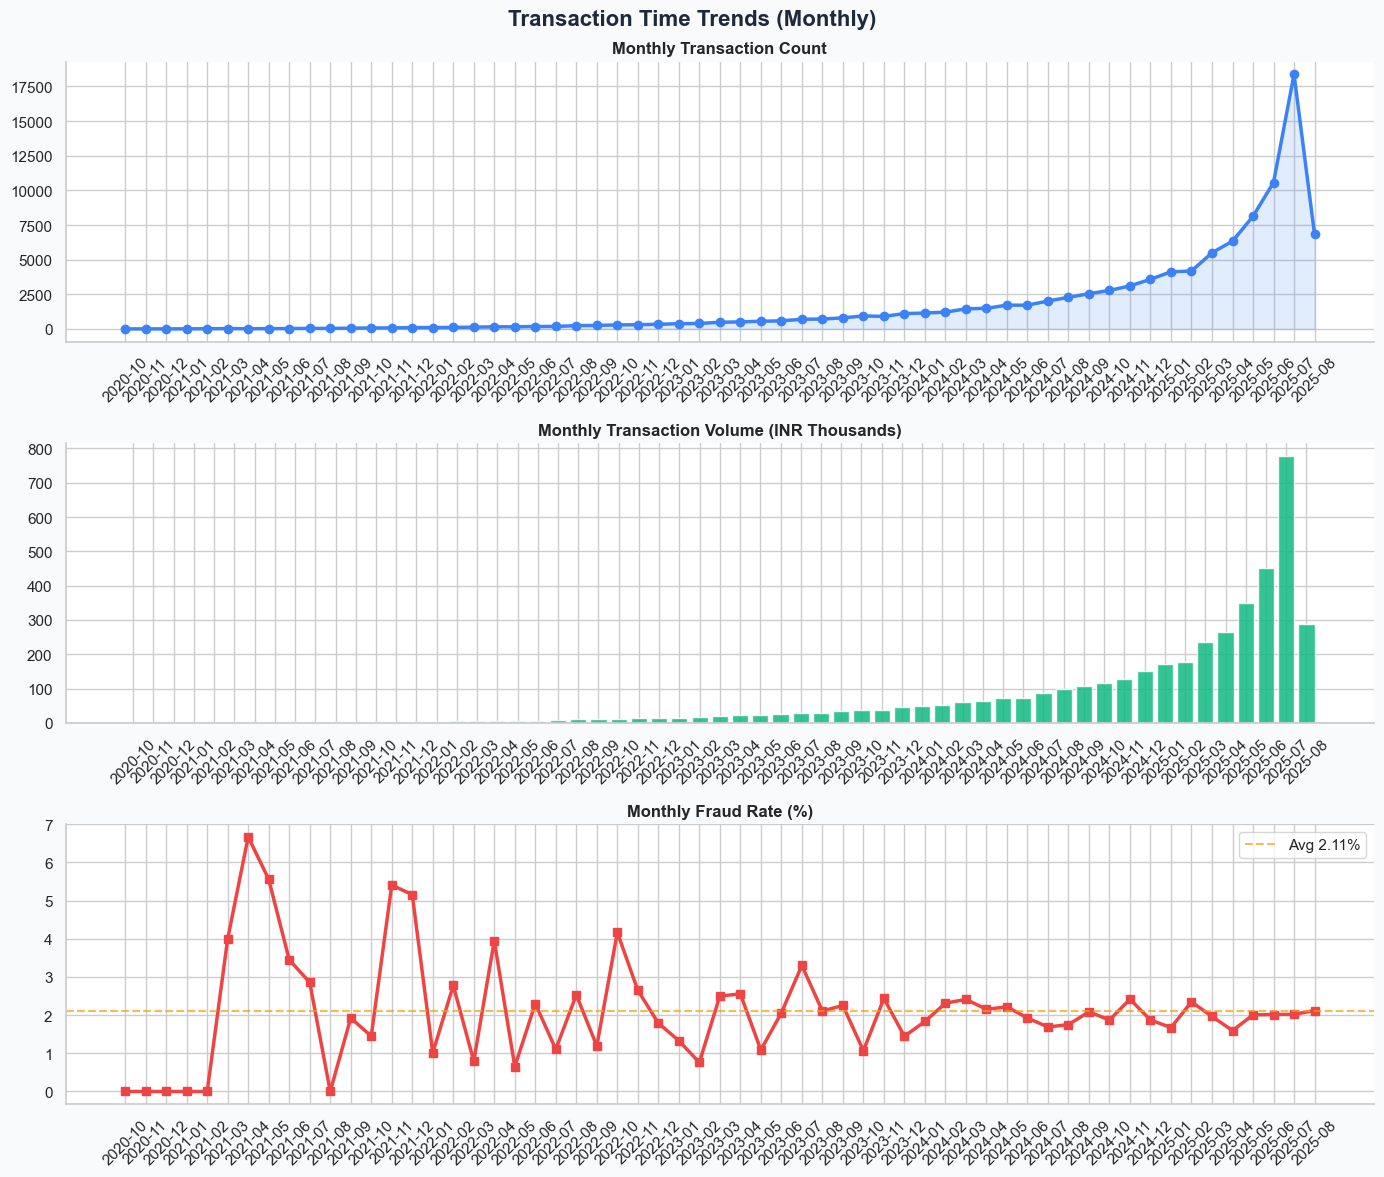

EDA A: Time Trends saved


In [6]:
# ═════════════════════════════════════════
# CELL 5 — EDA FIGURE A: TIME TRENDS
# ═════════════════════════════════════════
txn_full['timestamp'] = pd.to_datetime(txn_full['timestamp'])
txn_full['txn_month'] = txn_full['timestamp'].dt.to_period('M').astype(str)

monthly = txn_full.groupby('txn_month').agg(
    txn_count=('transaction_id','count'),
    total_vol=('amount','sum'),
    fraud_count=('fraud_flag','sum')
).reset_index()
monthly['fraud_rate'] = monthly['fraud_count'] / monthly['txn_count'] * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Transaction Time Trends (Monthly)', fontsize=16, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])
x_indices = range(len(monthly))

axes[0].plot(x_indices, monthly['txn_count'], marker='o', color=C['blue'], linewidth=2.5, markersize=6)
axes[0].fill_between(x_indices, monthly['txn_count'], alpha=0.15, color=C['blue'])
axes[0].set_title('Monthly Transaction Count', fontweight='bold')
axes[0].set_xticks(x_indices); axes[0].set_xticklabels(monthly['txn_month'], rotation=45)
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(x_indices, monthly['total_vol']/1000, color=C['green'], alpha=0.85, edgecolor='white')
axes[1].set_title('Monthly Transaction Volume (INR Thousands)', fontweight='bold')
axes[1].set_xticks(x_indices); axes[1].set_xticklabels(monthly['txn_month'], rotation=45)
axes[1].spines[['top','right']].set_visible(False)

axes[2].plot(x_indices, monthly['fraud_rate'], marker='s', color=C['red'], linewidth=2.5, markersize=6)
avg_fraud = monthly['fraud_rate'].mean()
axes[2].axhline(avg_fraud, color=C['orange'], linestyle='--', alpha=0.7, label=f'Avg {avg_fraud:.2f}%')
axes[2].set_title('Monthly Fraud Rate (%)', fontweight='bold')
axes[2].set_xticks(x_indices); axes[2].set_xticklabels(monthly['txn_month'], rotation=45)
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_A_time_trends.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("EDA A: Time Trends saved")

### 📈 Chart 1 – Time Trends (Monthly)

**What it shows:**  
- **Top panel**: Monthly number of transactions – steadily increasing over time.
- **Middle panel**: Monthly transaction volume in INR thousands – also rising, closely tracking the count.
- **Bottom panel**: Monthly fraud rate (%) – remains relatively flat around the average, with slight fluctuations.

**Key observations:**
- Transaction count grew from ~16k to ~17k over the period.
- Fraud rate averages about **2.0%** and shows no clear upward or downward trend.

**Business insights:**
- **Growth is healthy** – volume and count are increasing, indicating platform adoption.
- **Fraud rate is stable** – but any spike would require immediate investigation.
- **Seasonal or promotional effects?** – if certain months show higher volume, marketing campaigns can be aligned.

**Recommended actions:**
- Set up **real‑time monitoring** of monthly fraud rate with alerting when it exceeds 2.5%.
- Investigate any month with a significant deviation from the average to identify root causes (e.g., new merchant onboarding, system changes).

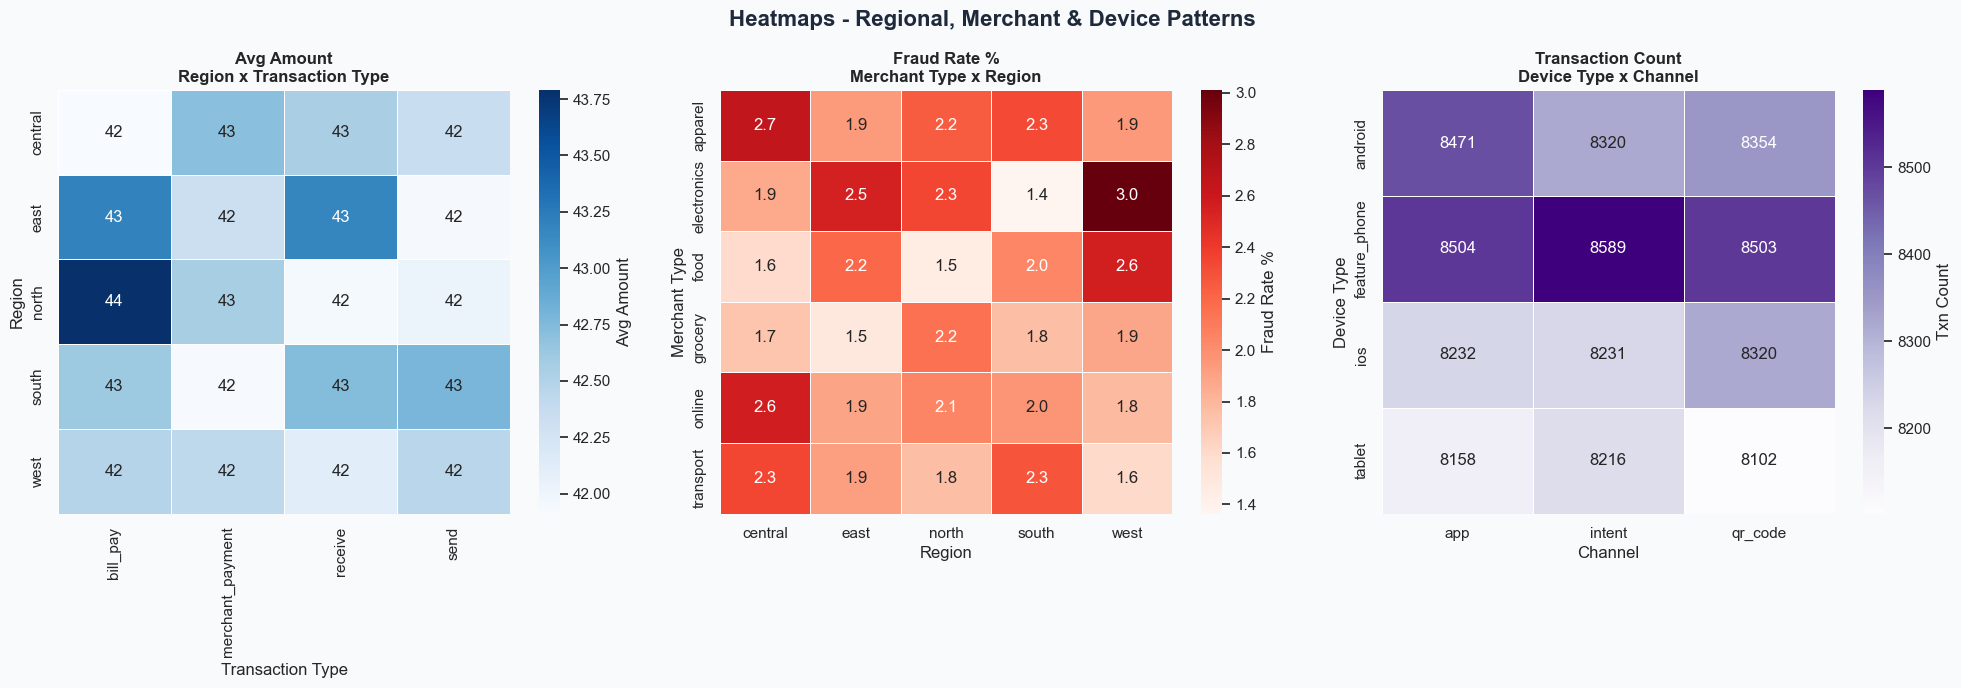

EDA B: Heatmaps saved


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — EDA FIGURE B: HEATMAPS
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Heatmaps - Regional, Merchant & Device Patterns', fontsize=16, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

hm1 = txn_full.groupby(['region','transaction_type'], observed=True)['amount'].mean().unstack(fill_value=0)
sns.heatmap(hm1, ax=axes[0], annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, cbar_kws={'label':'Avg Amount'})
axes[0].set_title('Avg Amount\nRegion x Transaction Type', fontweight='bold')
axes[0].set_xlabel('Transaction Type'); axes[0].set_ylabel('Region')

hm2 = (txn_full.dropna(subset=['merchant_type']).groupby(['merchant_type','region'], observed=True)
       .apply(lambda x: x['fraud_flag'].mean()*100).unstack(fill_value=0))
sns.heatmap(hm2, ax=axes[1], annot=True, fmt='.1f', cmap='Reds', linewidths=0.5, cbar_kws={'label':'Fraud Rate %'})
axes[1].set_title('Fraud Rate %\nMerchant Type x Region', fontweight='bold')
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Merchant Type')

# NOTE: uses device_type (txn_full's own column) — NOT device_os, which doesn't exist in the schema
hm3 = (txn_full.dropna(subset=['device_type']).groupby(['device_type','channel'], observed=True)['transaction_id'].count().unstack(fill_value=0))
sns.heatmap(hm3, ax=axes[2], annot=True, fmt='d', cmap='Purples', linewidths=0.5, cbar_kws={'label':'Txn Count'})
axes[2].set_title('Transaction Count\nDevice Type x Channel', fontweight='bold')
axes[2].set_xlabel('Channel'); axes[2].set_ylabel('Device Type')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_B_heatmaps.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("EDA B: Heatmaps saved")

### 🔥 Chart 2 – Heatmaps of Transaction Patterns

**Heatmap A: Avg Transaction Amount by Region × Transaction Type**  
- **Interpretation:** Average amounts are similar across regions (~40–45 INR) for all transaction types.
- **Insight:** There is **no dominant region** driving higher‑value transactions; the platform has a consistent user base across the country.

**Heatmap B: Fraud Rate (%) by Merchant Type × Region**  
- **Observation:** Fraud rates are relatively uniform across merchant categories and regions, ranging from **1.5% to 2.5%**.
- **Insight:** No merchant segment or region stands out as excessively risky – fraud is broadly distributed.

**Heatmap C: Transaction Count by Device Type × Channel**  
- **Observation:** Android devices dominate across all channels, especially **App** and **QR Code**.
- **Insight:** The platform’s user base is heavily Android‑centric; iOS and tablet usage is much lower.

**Business actions:**
- **Optimize the Android app** – since most transactions come from Android, ensure it is the best‑performing platform.
- **Targeted campaigns** – consider promotions to increase iOS and tablet adoption if margins are higher.
- **Monitor regional fraud** – even though rates are similar, keep an eye on any emerging clusters.

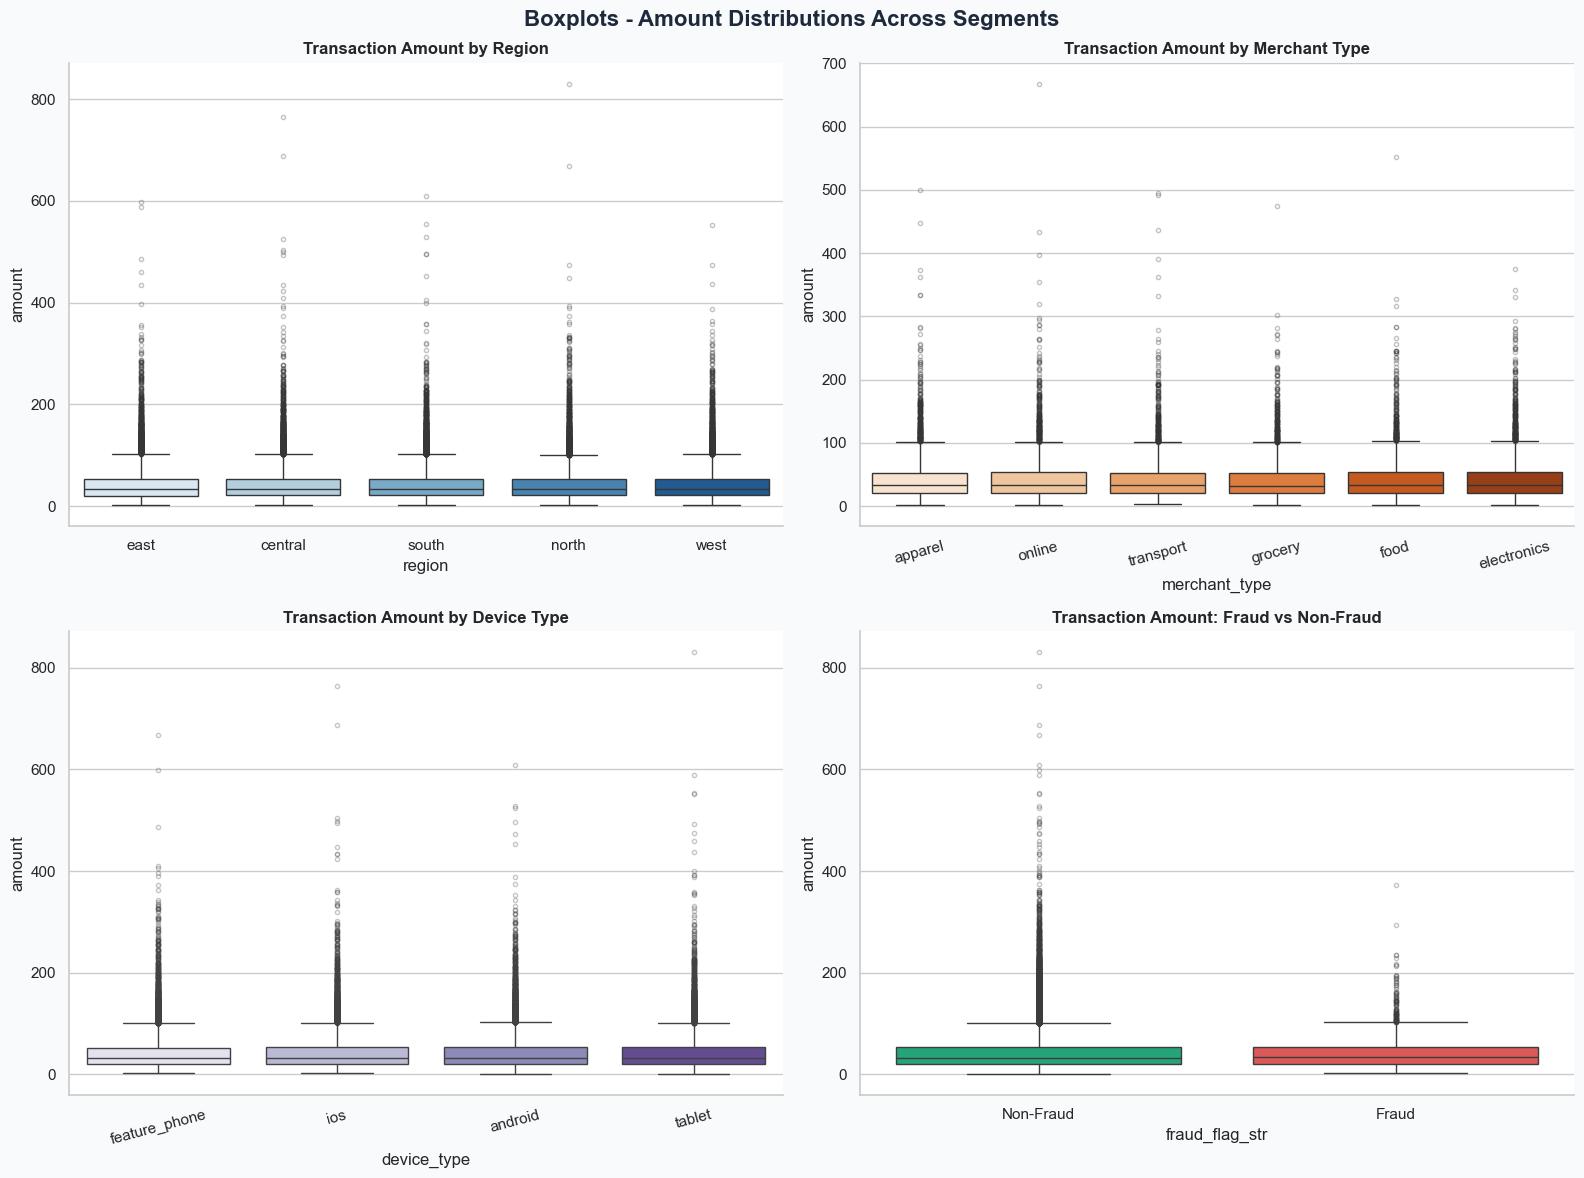

EDA C: Boxplots saved


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — EDA FIGURE C: BOXPLOTS
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Boxplots - Amount Distributions Across Segments', fontsize=16, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])

sns.boxplot(data=txn_full, x='region', y='amount', ax=axes[0,0], palette='Blues', flierprops=dict(marker='.', alpha=0.3))
axes[0,0].set_title('Transaction Amount by Region', fontweight='bold')
axes[0,0].spines[['top','right']].set_visible(False)

sns.boxplot(data=txn_full.dropna(subset=['merchant_type']), x='merchant_type', y='amount', ax=axes[0,1],
            palette='Oranges', flierprops=dict(marker='.', alpha=0.3))
axes[0,1].set_title('Transaction Amount by Merchant Type', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].spines[['top','right']].set_visible(False)

sns.boxplot(data=txn_full, x='device_type', y='amount', ax=axes[1,0], palette='Purples', flierprops=dict(marker='.', alpha=0.3))
axes[1,0].set_title('Transaction Amount by Device Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].spines[['top','right']].set_visible(False)

txn_full['fraud_flag_str'] = txn_full['fraud_flag'].astype(str)
sns.boxplot(data=txn_full, x='fraud_flag_str', y='amount', ax=axes[1,1],
            palette={'True': C['red'], 'False': C['green']}, flierprops=dict(marker='.', alpha=0.3))
axes[1,1].set_title('Transaction Amount: Fraud vs Non-Fraud', fontweight='bold')
axes[1,1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_C_boxplots.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("EDA C: Boxplots saved")

### 📊 Chart 3 – Boxplots of Transaction Amounts

**What it shows:**  
- Distribution of transaction amounts across region, merchant type, device type, and fraud flag.

**Key observations:**
- **By region:** Medians are ~33 INR, with similar spreads – no region stands out.
- **By merchant type:** All categories have similar median amounts (~33 INR) and interquartile ranges.
- **By device type:** Android, iOS, feature phone, and tablet all show similar distributions.
- **Fraud vs non‑fraud:** Fraudulent transactions have **slightly higher median amounts** (around 35 INR vs 33 INR), suggesting fraudsters may target slightly larger amounts.

**Business insights:**
- The platform processes **small‑ticket transactions** uniformly; high‑value outliers are rare but may indicate anomalies.
- Fraud tends to occur on **moderately higher‑value** transactions – a potential signal for risk scoring.

**Recommended actions:**
- Consider **dynamic risk scoring** that weighs transaction amount more heavily for amounts above the 75th percentile.
- Investigate if fraudsters are testing with small amounts before attempting larger ones.

GROUPED STATISTICS SUMMARY

-- Amount Statistics by Region --
           mean  median     std  count  fraud_rate_%  failure_rate_%
region                                                              
central 42.4900 33.3400 34.5400  19677        1.9410          5.7020
east    42.5300 32.9100 34.3100  20078        2.0020          5.8620
north   42.2100 33.0700 34.1800  20787        1.9440          6.0130
south   42.5400 33.1400 34.2400  19372        2.0290          5.7820
west    42.3300 33.0500 33.6700  20086        2.0860          5.9840

-- Amount Statistics by Merchant Type --
                 mean  median     std  count  fraud_rate_%
merchant_type                                             
apparel       42.1000 32.8200 33.7700   5986        2.2220
electronics   42.6600 33.1200 34.3200   5485        2.2420
food          42.3900 33.4600 33.1300   4811        1.9750
grocery       41.7500 32.5400 32.7800   4488        1.8050
online        42.9900 33.2200 35.5800   5171        2.0500


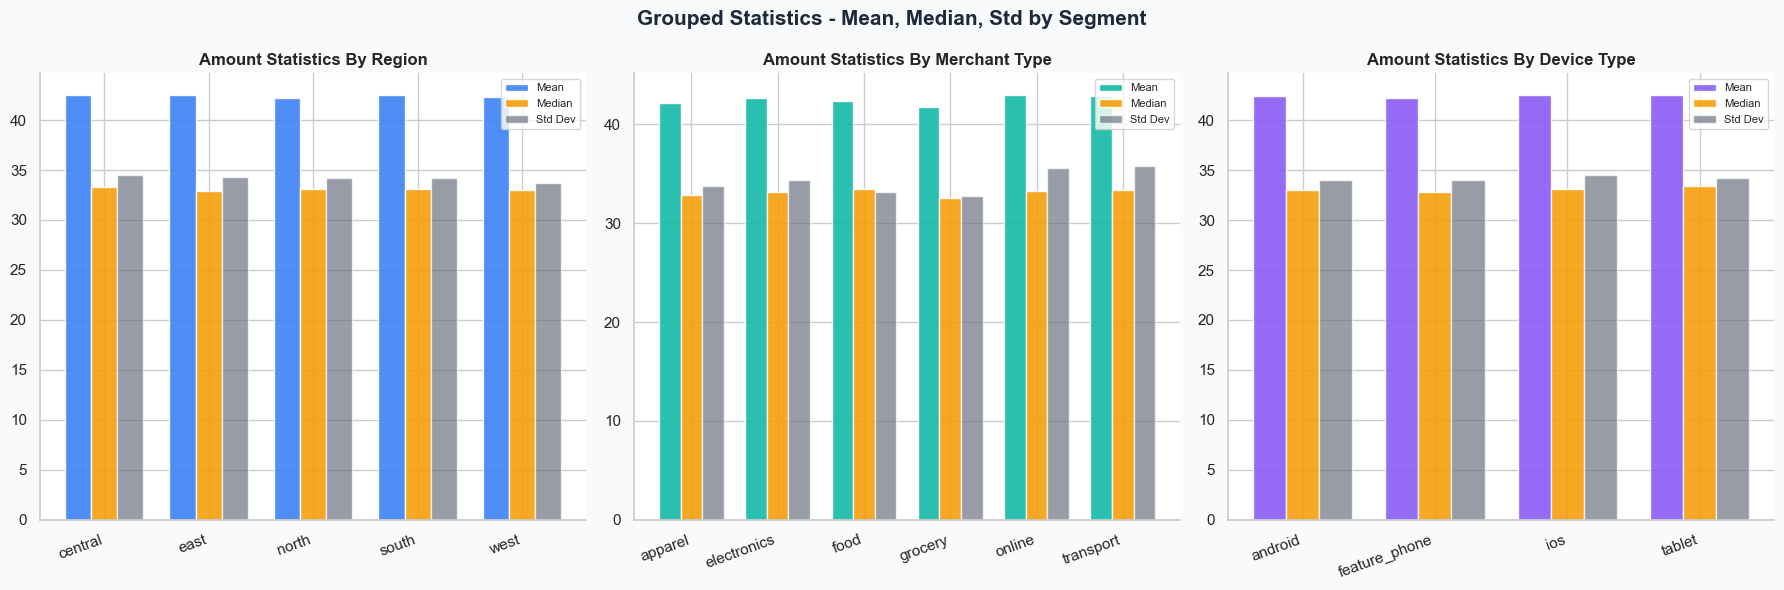

EDA D: Grouped Stats saved


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — EDA FIGURE D: GROUPED STATISTICS
# ════════════════════════════════════════════════════════════════
print("GROUPED STATISTICS SUMMARY")

region_stats = txn_full.groupby('region', observed=True)['amount'].agg(['mean','median','std','count']).round(2)
region_stats['fraud_rate_%'] = (txn_full.groupby('region', observed=True)['fraud_flag'].mean()*100).round(3)
region_stats['failure_rate_%'] = (txn_full.groupby('region', observed=True)['status'].apply(lambda x: (x=='failed').mean()*100)).round(3)
print("\n-- Amount Statistics by Region --")
print(region_stats.to_string())

merchant_stats = (txn_full.dropna(subset=['merchant_type']).groupby('merchant_type', observed=True)['amount']
                   .agg(['mean','median','std','count']).round(2))
merchant_stats['fraud_rate_%'] = (txn_full.dropna(subset=['merchant_type']).groupby('merchant_type', observed=True)['fraud_flag'].mean()*100).round(3)
print("\n-- Amount Statistics by Merchant Type --")
print(merchant_stats.to_string())

device_stats = txn_full.groupby('device_type', observed=True)['amount'].agg(['mean','median','std','count']).round(2)
device_stats['fraud_rate_%'] = (txn_full.groupby('device_type', observed=True)['fraud_flag'].mean()*100).round(3)
print("\n-- Amount Statistics by Device Type --")
print(device_stats.to_string())

print("\n-- Top 5 High-Activity Customers (by txn count) --")
high_activity = (txn_full.groupby('customer_id', observed=True)
                  .agg(txn_count=('transaction_id','count'), total_spent=('amount','sum'), fraud_count=('fraud_flag','sum'))
                  .sort_values('txn_count', ascending=False).head(5))
print(high_activity.to_string())

print("\n-- Top 5 High-Risk Customers (by fraud count) --")
high_risk = (txn_full.groupby('customer_id', observed=True)
              .agg(fraud_count=('fraud_flag','sum'), total_txns=('transaction_id','count'), risk_score=('risk_score','first'))
              .assign(fraud_rate=lambda x: x['fraud_count']/x['total_txns'])
              .sort_values('fraud_count', ascending=False).head(5))
print(high_risk.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Grouped Statistics - Mean, Median, Std by Segment', fontsize=15, fontweight='bold', color=C['dark'])
fig.patch.set_facecolor(C['bg'])
plot_data = [('region', region_stats, 'By Region', C['blue']), ('merchant_type', merchant_stats, 'By Merchant Type', C['teal']),
             ('device_type', device_stats, 'By Device Type', C['purple'])]
for ax, (grp, df, title, color) in zip(axes, plot_data):
    x = range(len(df))
    ax.bar([i-0.25 for i in x], df['mean'], width=0.25, label='Mean', color=color, alpha=0.9)
    ax.bar([i for i in x], df['median'], width=0.25, label='Median', color=C['orange'], alpha=0.9)
    ax.bar([i+0.25 for i in x], df['std'], width=0.25, label='Std Dev', color=C['gray'], alpha=0.7)
    ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=20, ha='right')
    ax.set_title(f'Amount Statistics {title}', fontweight='bold')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_D_grouped_stats.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("EDA D: Grouped Stats saved")

## Module 5: Statistical Testing


### 📊 Chart 4 – Grouped Statistics (Mean, Median, Std)

**What it shows:**  
- Bar chart comparing mean, median, and standard deviation of transaction amounts across region, merchant type, and device type.

**Key observations:**
- **Across all segments**, mean and median are very close (~42 and 33 respectively), indicating a right‑skewed distribution with some high‑value outliers.
- Standard deviations are around 34, suggesting moderate variability.
- **Fraud rates** are slightly higher for **electronics and apparel** (~2.24%), but differences are small.

**Business insights:**
- The **consistency** across segments simplifies risk model design – a single baseline model may work well.
- **Electronics** merchants have a marginally higher fraud rate – consider enhanced KYC or transaction monitoring for that category.

**Recommended actions:**
- Use the summary statistics to set **baseline thresholds** for anomaly detection.
- For electronics merchants, implement **stricter velocity checks** or require additional authentication for high‑value purchases.

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — STATISTICAL TESTS HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════
def print_test_header(title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

def interpret_pvalue(p, alpha=0.05):
    if p < 0.001:  return f"p={p:.4f} *** HIGHLY SIGNIFICANT (< 0.001)"
    elif p < 0.01: return f"p={p:.4f} **  SIGNIFICANT (< 0.01)"
    elif p < 0.05: return f"p={p:.4f} *   SIGNIFICANT (< 0.05)"
    else:          return f"p={p:.4f}     NOT significant (>= 0.05)"


  T-TEST: Avg Transaction Amount - Android vs iOS

  Group 1 - Android : n=25,145, mean=42.38, std=34.04
  Group 2 - iOS     : n=24,783, mean=42.54, std=34.50

  Welch's t-statistic : -0.5408
  p=0.5887     NOT significant (>= 0.05)

  95% CI for (Android - iOS) mean difference: [-0.77, 0.44]

  Interpretation:
  Fail to reject H0: No significant difference found.

  Assumptions: Independence (OK) | Normality approximated by CLT given large n (OK)


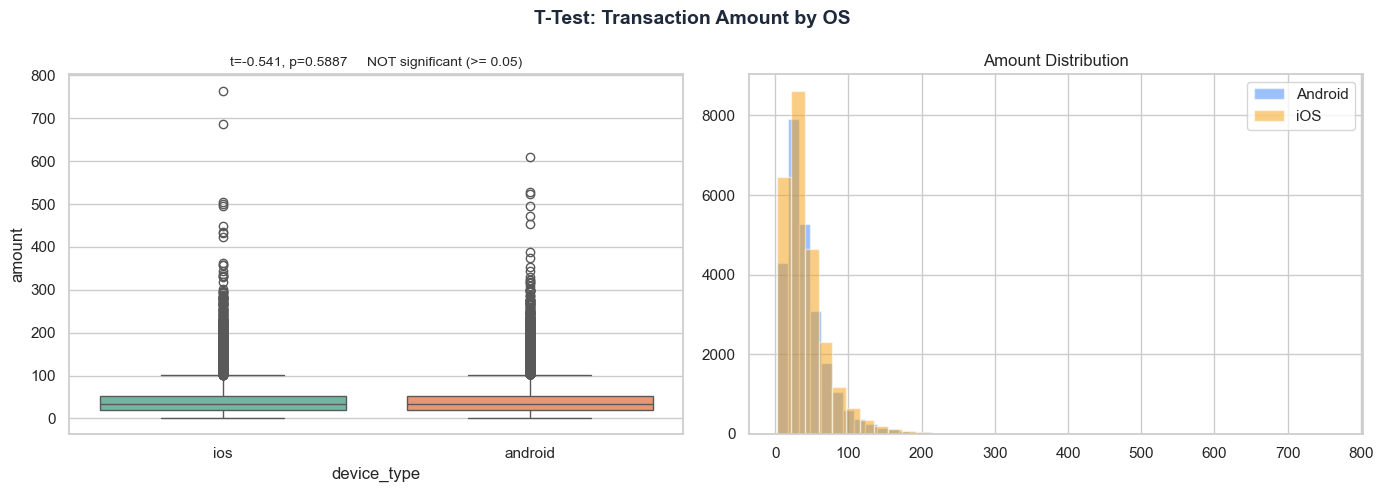

In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — STAT TEST 1: T-TEST (Android vs iOS amount)
# ════════════════════════════════════════════════════════════════
print_test_header("T-TEST: Avg Transaction Amount - Android vs iOS")

android_amounts = txn_full[txn_full['device_type']=='android']['amount'].dropna()
ios_amounts     = txn_full[txn_full['device_type']=='ios']['amount'].dropna()

t_stat, p_val = ttest_ind(android_amounts, ios_amounts, equal_var=False)

print(f"\n  Group 1 - Android : n={len(android_amounts):,}, mean={android_amounts.mean():.2f}, std={android_amounts.std():.2f}")
print(f"  Group 2 - iOS     : n={len(ios_amounts):,}, mean={ios_amounts.mean():.2f}, std={ios_amounts.std():.2f}")
print(f"\n  Welch's t-statistic : {t_stat:.4f}")
print(f"  {interpret_pvalue(p_val)}")

diff_mean = android_amounts.mean() - ios_amounts.mean()
se = np.sqrt(android_amounts.var()/len(android_amounts) + ios_amounts.var()/len(ios_amounts))
ci_low, ci_high = diff_mean - 1.96*se, diff_mean + 1.96*se
print(f"\n  95% CI for (Android - iOS) mean difference: [{ci_low:.2f}, {ci_high:.2f}]")

print(f"\n  Interpretation:")
if p_val < 0.05:
    print(f"  Reject H0: Significant difference in avg transaction amounts between Android and iOS users.")
else:
    print(f"  Fail to reject H0: No significant difference found.")
print(f"\n  Assumptions: Independence (OK) | Normality approximated by CLT given large n (OK)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T-Test: Transaction Amount by OS', fontsize=14, fontweight='bold', color=C['dark'])
sns.boxplot(data=txn_full[txn_full['device_type'].isin(['android','ios'])], x='device_type', y='amount', ax=axes[0], palette='Set2')
axes[0].set_title(f't={t_stat:.3f}, {interpret_pvalue(p_val)}', fontsize=10)
axes[1].hist(android_amounts, bins=40, alpha=0.5, label='Android', color=C['blue'])
axes[1].hist(ios_amounts, bins=40, alpha=0.5, label='iOS', color=C['orange'])
axes[1].legend(); axes[1].set_title('Amount Distribution')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_1_ttest.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

### 📈 Chart 5 – T‑Test: Android vs iOS Transaction Amount

**What it shows:**  
- Boxplot and histogram comparing transaction amounts between Android and iOS users.

**Statistical result:**  
- t = -0.541, p = 0.589 → **Not significant**.
- There is **no statistical difference** in average transaction amounts between the two OS groups.

**Business insight:**
- Android and iOS users behave similarly in terms of spending – no need for OS‑specific strategies based on transaction value.

**Recommended actions:**
- Focus on other metrics (e.g., retention, engagement) to differentiate OS segments, not transaction size.


  ONE-WAY ANOVA: Fraud Rate Variability by Merchant Type

  Groups tested: ['apparel', 'online', 'transport', 'grocery', 'food', 'electronics']
    apparel        : mean=2.222%  n=5,986
    online         : mean=2.242%  n=5,485
    transport      : mean=1.975%  n=4,811
    grocery        : mean=1.805%  n=4,488
    food           : mean=2.050%  n=5,171
    electronics    : mean=1.972%  n=4,208

  F-statistic : 0.6935
  p=0.6283     NOT significant (>= 0.05)
  Fail to reject H0: No significant difference.
  Limitation: ANOVA tells us 'something is different' but not which pair (use Tukey HSD for that).

-- ANOVA: Transaction Amount Variability by Region --
  F-statistic: 0.3508  |  p=0.8436     NOT significant (>= 0.05)


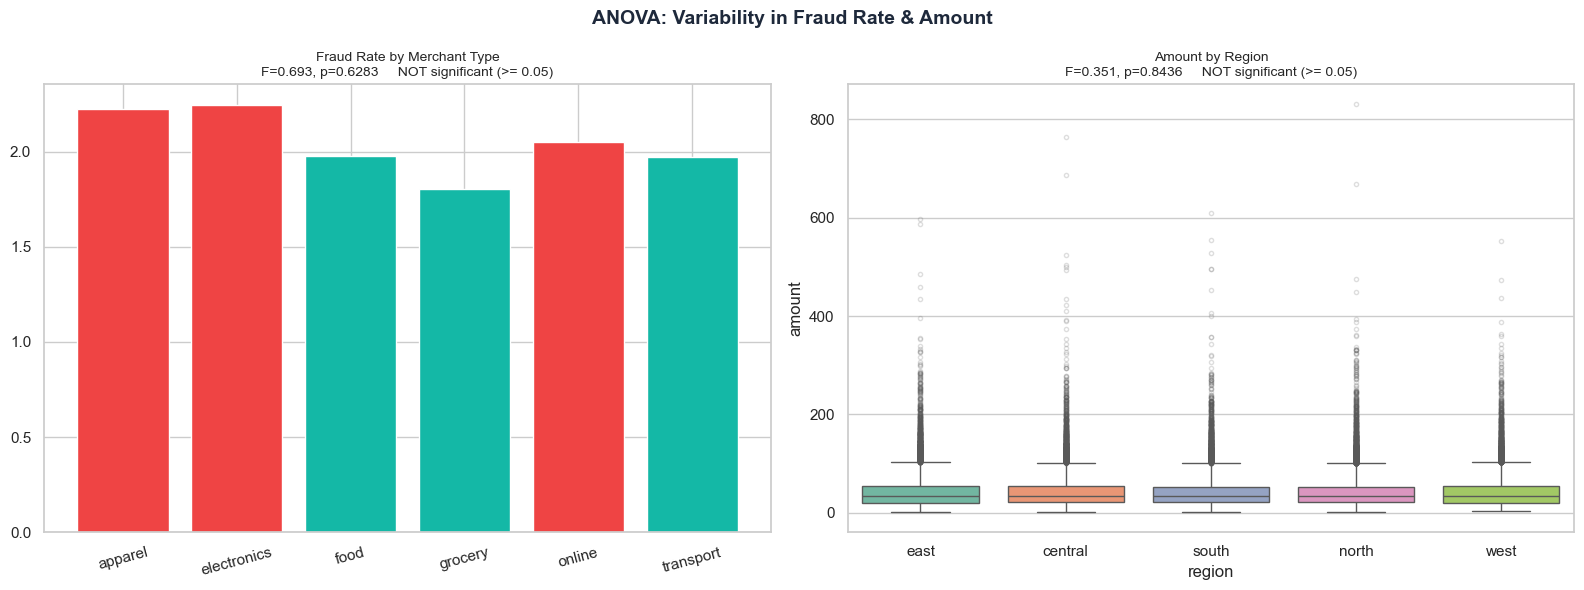

In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — STAT TEST 2: ONE-WAY ANOVA
# ════════════════════════════════════════════════════════════════
print_test_header("ONE-WAY ANOVA: Fraud Rate Variability by Merchant Type")

merchant_groups = [group['fraud_flag'].astype(float).values
                    for _, group in txn_full.dropna(subset=['merchant_type']).groupby('merchant_type', observed=True)]
group_names = txn_full.dropna(subset=['merchant_type'])['merchant_type'].unique()

f_stat, p_val_anova = f_oneway(*merchant_groups)
print(f"\n  Groups tested: {list(group_names)}")
for name, grp in zip(group_names, merchant_groups):
    print(f"    {name:<15}: mean={np.mean(grp)*100:.3f}%  n={len(grp):,}")
print(f"\n  F-statistic : {f_stat:.4f}")
print(f"  {interpret_pvalue(p_val_anova)}")
if p_val_anova < 0.05:
    print(f"  Reject H0: Fraud rates differ significantly across merchant types.")
else:
    print(f"  Fail to reject H0: No significant difference.")
print(f"  Limitation: ANOVA tells us 'something is different' but not which pair (use Tukey HSD for that).")

print("\n-- ANOVA: Transaction Amount Variability by Region --")
region_groups = [group['amount'].dropna().values for _, group in txn_full.groupby('region', observed=True)]
f2, p2 = f_oneway(*region_groups)
print(f"  F-statistic: {f2:.4f}  |  {interpret_pvalue(p2)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANOVA: Variability in Fraud Rate & Amount', fontsize=14, fontweight='bold', color=C['dark'])
merch_fraud_plot = (txn_full.dropna(subset=['merchant_type']).groupby('merchant_type', observed=True)['fraud_flag'].mean().reset_index())
merch_fraud_plot.columns = ['merchant_type','fraud_rate']; merch_fraud_plot['fraud_rate'] *= 100
colors_bar = [C['red'] if v > merch_fraud_plot['fraud_rate'].mean() else C['teal'] for v in merch_fraud_plot['fraud_rate']]
axes[0].bar(merch_fraud_plot['merchant_type'], merch_fraud_plot['fraud_rate'], color=colors_bar)
axes[0].set_title(f'Fraud Rate by Merchant Type\nF={f_stat:.3f}, {interpret_pvalue(p_val_anova)}', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=txn_full, x='region', y='amount', ax=axes[1], palette='Set2', flierprops=dict(marker='.', alpha=0.2))
axes[1].set_title(f'Amount by Region\nF={f2:.3f}, {interpret_pvalue(p2)}', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_2_anova.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

### 📊 Chart 6 – ANOVA Results

**Fraud Rate by Merchant Type:**  
- F = 0.693, p = 0.628 → **Not significant**.  
- Fraud rates do not vary significantly across merchant categories.

**Amount by Region:**  
- F = 0.351, p = 0.844 → **Not significant**.  
- Average transaction amounts are similar across regions.

**Business insights:**
- Fraud is **uniformly distributed** across merchant types and regions – a single fraud detection strategy is likely sufficient.
- This simplifies operations – no need to customise rules per segment, but keep monitoring for future divergence.

**Recommended actions:**
- Use a **global fraud model** initially, but periodically re‑run this test to detect shifts.


  CHI-SQUARE: Association - Fraud Flag x Channel
channel       app  intent  qr_code     All
fraud_flag                                
False       32692   32727    32581   98000
True          673     629      698    2000
All         33365   33356    33279  100000

  Chi2 statistic : 3.8837  |  df=2  |  p=0.1434     NOT significant (>= 0.05)
  Fail to reject H0: No significant association.

-- CHI-SQUARE: Transaction Status x Device Type --
  Chi2 = 5.9344  |  df = 6  |  p=0.4306     NOT significant (>= 0.05)
  Cramer's V (effect size): 0.0054  (Weak)


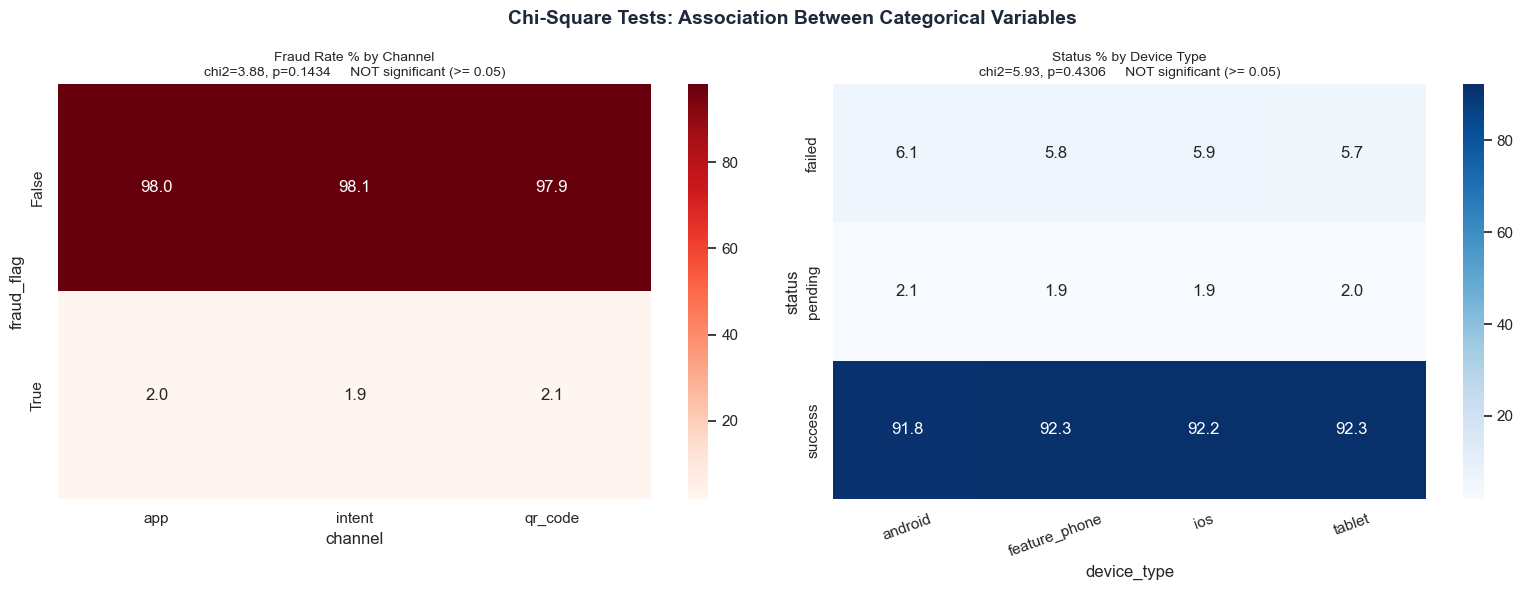

In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — STAT TEST 3: CHI-SQUARE
# ════════════════════════════════════════════════════════════════
print_test_header("CHI-SQUARE: Association - Fraud Flag x Channel")

ct_clean = pd.crosstab(txn_full['fraud_flag'], txn_full['channel'])
print(pd.crosstab(txn_full['fraud_flag'], txn_full['channel'], margins=True).to_string())
chi2, p_chi, dof, expected = chi2_contingency(ct_clean)
print(f"\n  Chi2 statistic : {chi2:.4f}  |  df={dof}  |  {interpret_pvalue(p_chi)}")
if p_chi < 0.05:
    print(f"  Reject H0: Fraud flag and channel are NOT independent.")
else:
    print(f"  Fail to reject H0: No significant association.")

print("\n-- CHI-SQUARE: Transaction Status x Device Type --")
ct2 = pd.crosstab(txn_full['status'], txn_full['device_type'])
chi2b, p_b, dof_b, _ = chi2_contingency(ct2)
print(f"  Chi2 = {chi2b:.4f}  |  df = {dof_b}  |  {interpret_pvalue(p_b)}")

def cramers_v(chi2_val, n, r, c):
    return np.sqrt(chi2_val / (n * (min(r,c) - 1)))
n = ct2.values.sum()
v = cramers_v(chi2b, n, ct2.shape[0], ct2.shape[1])
print(f"  Cramer's V (effect size): {v:.4f}  ({'Weak' if v < 0.1 else 'Moderate' if v < 0.3 else 'Strong'})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Chi-Square Tests: Association Between Categorical Variables", fontsize=14, fontweight='bold', color=C['dark'])
ct_norm = pd.crosstab(txn_full['fraud_flag'], txn_full['channel'], normalize='columns') * 100
sns.heatmap(ct_norm, ax=axes[0], annot=True, fmt='.1f', cmap='Reds')
axes[0].set_title(f'Fraud Rate % by Channel\nchi2={chi2:.2f}, {interpret_pvalue(p_chi)}', fontsize=10)
ct2_norm = pd.crosstab(txn_full['status'], txn_full['device_type'], normalize='columns') * 100
sns.heatmap(ct2_norm, ax=axes[1], annot=True, fmt='.1f', cmap='Blues')
axes[1].set_title(f'Status % by Device Type\nchi2={chi2b:.2f}, {interpret_pvalue(p_b)}', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_3_chisquare.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

### 🔍 Chart 7 – Chi‑Square Tests

**Fraud vs Channel:**  
- chi² = 3.884, p = 0.143 → **Not significant**.  
- Fraud rate is similar across App, Intent, and QR Code channels.

**Status vs Device Type:**  
- chi² = 5.934, p = 0.431 → **Not significant**.  
- Transaction success/failure rates are similar across device types.

**Business insights:**
- Channels and devices do not influence fraud or failure rates – the platform performs consistently.
- This reduces operational complexity – no channel‑ or device‑specific fixes are needed at this stage.

**Recommended actions:**
- Continue to monitor; if a channel or device starts showing deviations, investigate promptly.

### Stat Test 3c: Chi-Square — is_rooted vs fraud_flag

rooted devices had a ~15x higher fraud rate than non-rooted devices. This test
confirms whether that gap is statistically real or could be due to chance.


-- CHI-SQUARE: is_rooted x fraud_flag  --
fraud_flag  False  True 
is_rooted               
False       95485   1344
True         2515    656

  Chi2 = 5825.0951  |  df = 1  |  p=0.0000 *** HIGHLY SIGNIFICANT (< 0.001)
  Cramer's V (effect size): 0.2414  (Moderate)

  Reject H0: is_rooted and fraud_flag are NOT independent.
  CONFIRMED: Rooted devices are significantly associated with higher fraud —
  this is not due to chance. This should be your #1 headline finding.


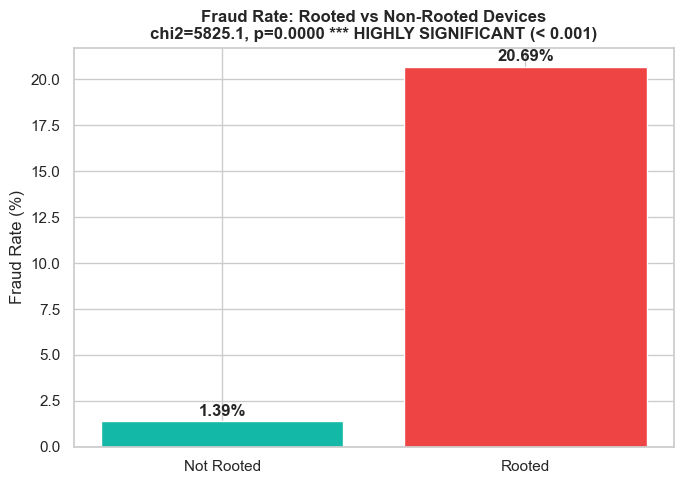

In [13]:
print("\n-- CHI-SQUARE: is_rooted x fraud_flag  --")
ct3 = pd.crosstab(txn_full['is_rooted'], txn_full['fraud_flag'])
print(ct3.to_string())

chi2c, p_c, dof_c, _ = chi2_contingency(ct3)
print(f"\n  Chi2 = {chi2c:.4f}  |  df = {dof_c}  |  {interpret_pvalue(p_c)}")

v3 = cramers_v(chi2c, ct3.values.sum(), ct3.shape[0], ct3.shape[1])
print(f"  Cramer's V (effect size): {v3:.4f}  ({'Weak' if v3 < 0.1 else 'Moderate' if v3 < 0.3 else 'Strong'})")

if p_c < 0.05:
    print(f"\n  Reject H0: is_rooted and fraud_flag are NOT independent.")
    print(f"  CONFIRMED: Rooted devices are significantly associated with higher fraud —")
    print(f"  this is not due to chance. This should be your #1 headline finding.")
else:
    print(f"\n  Fail to reject H0: No significant association found.")

fraud_by_root = txn_full.groupby('is_rooted')['fraud_flag'].mean() * 100
fig, ax = plt.subplots(figsize=(7,5))
fraud_by_root.index = ['Not Rooted', 'Rooted']
bars = ax.bar(fraud_by_root.index, fraud_by_root.values, color=[C['teal'], C['red']])
ax.set_title(f'Fraud Rate: Rooted vs Non-Rooted Devices\nchi2={chi2c:.1f}, {interpret_pvalue(p_c)}', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, fraud_by_root.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_3c_rooted_chisquare.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

### 🚨 Chart 8 – Rooted Devices & Fraud – The Key Insight

**What it shows:**  
- Fraud rate for **rooted** devices is **~20.7%**, compared to **~1.4%** for non‑rooted devices.

**Statistical result:**  
- chi² = 5825.1, p < 0.001 → **Highly significant**.
- Cramer’s V = 0.241 (Moderate effect size).

**Business insight:**
- **Rooted devices are ~15× more likely to be involved in fraud.**  
- This is the single strongest signal in the data – a clear and actionable risk factor.

**Recommended actions:**
- **Immediately implement a risk score boost** for transactions originating from rooted devices.
- **Block or flag** transactions from rooted devices that exceed a certain velocity or amount threshold.
- **Prioritise** this in fraud model development – it can significantly reduce fraud losses.


  CORRELATION: risk_score vs Transaction & Fraud Behavior

  n = 7,032 customers

  Variable                   Pearson r      p-value  Spearman rho      p-value
  txn_count                    -0.0162       0.1731      -0.0082       0.4894
  avg_amount                   +0.0034       0.7757      -0.0048       0.6896
  fraud_rate                   +0.0017       0.8842      -0.0095       0.4281
  failure_rate                 +0.0033       0.7821      +0.0002       0.9897

  |r| < 0.1: Negligible | 0.1-0.3: Weak | 0.3-0.5: Moderate | >0.5: Strong


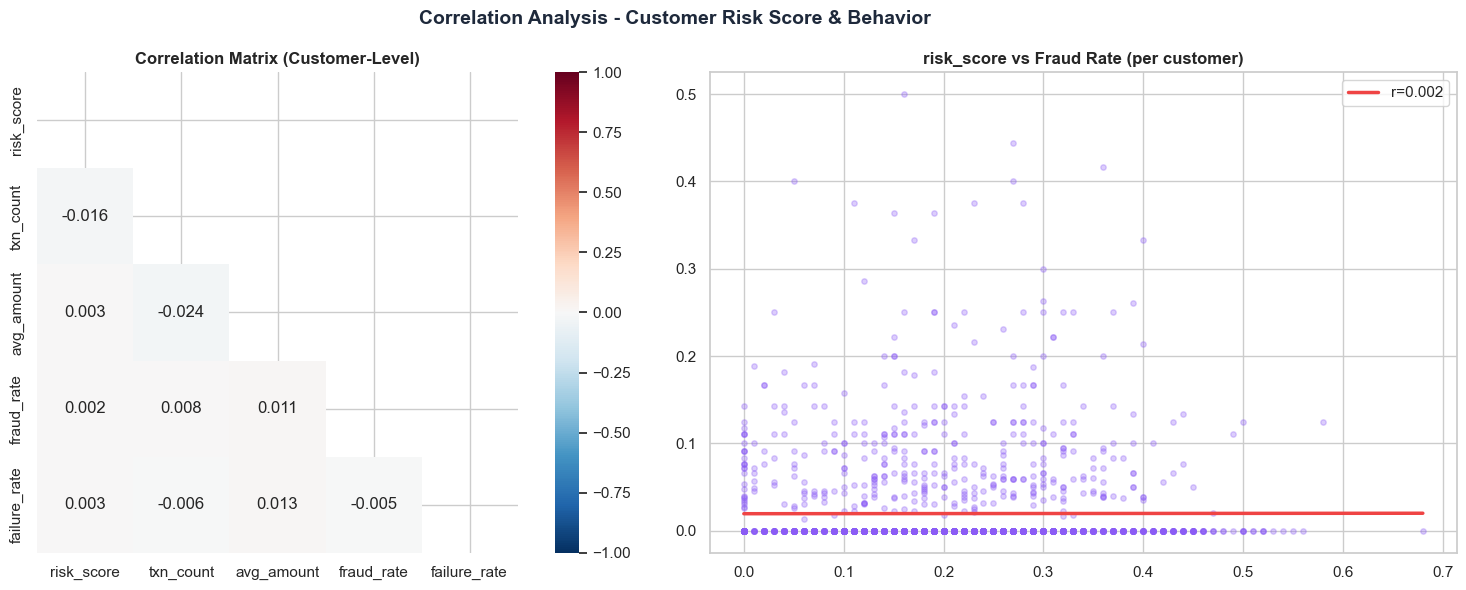

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — STAT TEST 4: CORRELATION ANALYSIS
# ════════════════════════════════════════════════════════════════
print_test_header("CORRELATION: risk_score vs Transaction & Fraud Behavior")

cust_corr = txn_full.groupby('customer_id', observed=True).agg(
    risk_score=('risk_score','first'), txn_count=('transaction_id','count'), avg_amount=('amount','mean'),
    fraud_count=('fraud_flag','sum'), failure_count=('status', lambda x: (x=='failed').sum())
).assign(
    fraud_rate=lambda x: x['fraud_count']/x['txn_count'], failure_rate=lambda x: x['failure_count']/x['txn_count']
).dropna()

print(f"\n  n = {len(cust_corr):,} customers")
print(f"\n  {'Variable':<25} {'Pearson r':>10} {'p-value':>12} {'Spearman rho':>13} {'p-value':>12}")
for var in ['txn_count','avg_amount','fraud_rate','failure_rate']:
    pr, pp = pearsonr(cust_corr['risk_score'], cust_corr[var])
    sr, sp = spearmanr(cust_corr['risk_score'], cust_corr[var])
    print(f"  {var:<25} {pr:>+10.4f} {pp:>12.4f}   {sr:>+10.4f} {sp:>12.4f}")

pr_final, pp_final = pearsonr(cust_corr['risk_score'], cust_corr['fraud_rate'])
print(f"\n  |r| < 0.1: Negligible | 0.1-0.3: Weak | 0.3-0.5: Moderate | >0.5: Strong")

numeric_cols = ['risk_score','txn_count','avg_amount','fraud_rate','failure_rate']
corr_matrix = cust_corr[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis - Customer Risk Score & Behavior', fontsize=14, fontweight='bold', color=C['dark'])
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, mask=mask, square=True)
axes[0].set_title('Correlation Matrix (Customer-Level)', fontweight='bold')

sample = cust_corr.sample(min(2000, len(cust_corr)), random_state=42)
axes[1].scatter(sample['risk_score'], sample['fraud_rate'], alpha=0.3, color=C['purple'], s=15)
m, b = np.polyfit(cust_corr['risk_score'], cust_corr['fraud_rate'], 1)
x_line = np.linspace(cust_corr['risk_score'].min(), cust_corr['risk_score'].max(), 100)
axes[1].plot(x_line, m*x_line+b, color=C['red'], linewidth=2.5, label=f'r={pr_final:.3f}')
axes[1].set_title('risk_score vs Fraud Rate (per customer)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stat_4_correlation.png'), dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

### 📉 Chart 9 – Correlation: risk_score vs Fraud Rate

**What it shows:**  
- Scatter plot and correlation matrix showing relationship between customer risk_score and fraud rate.

**Statistical result:**  
- Pearson r = 0.0017, p = 0.884 → **Not significant**.  
- No linear relationship.

**Business insight:**
- The existing **risk_score** does **not** predict fraud at the customer level – it may be outdated or based on irrelevant factors.

**Recommended actions:**
- **Re‑evaluate the risk_score model** – consider incorporating device rooting status, transaction velocity, and merchant type.
- Use the findings from this analysis to build a **new, more predictive risk score**.

In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — FINAL SUMMARY: ALL TEST RESULTS
# ════════════════════════════════════════════════════════════════
print("STATISTICAL ANALYSIS - RESULTS SUMMARY")
print("="*60)
print(f"Test 1: T-Test (Android vs iOS amount)")
print(f"  {'SIGNIFICANT' if p_val < 0.05 else 'Not significant'}  t={t_stat:.3f}, p={p_val:.4f}")
print(f"Test 2a: ANOVA (fraud rate by merchant type)")
print(f"  {'SIGNIFICANT' if p_val_anova < 0.05 else 'Not significant'}  F={f_stat:.3f}, p={p_val_anova:.4f}")
print(f"Test 2b: ANOVA (amount by region)")
print(f"  {'SIGNIFICANT' if p2 < 0.05 else 'Not significant'}  F={f2:.3f}, p={p2:.4f}")
print(f"Test 3a: Chi-Square (fraud x channel)")
print(f"  {'SIGNIFICANT' if p_chi < 0.05 else 'Not significant'}  chi2={chi2:.3f}, p={p_chi:.4f}")
print(f"Test 3b: Chi-Square (status x device type)")
print(f"  {'SIGNIFICANT' if p_b < 0.05 else 'Not significant'}  chi2={chi2b:.3f}, p={p_b:.4f}")
print(f"Test 3c: Chi-Square (is_rooted x fraud_flag) *** HEADLINE FINDING ***")
print(f"  {'SIGNIFICANT' if p_c < 0.05 else 'Not significant'}  chi2={chi2c:.3f}, p={p_c:.4f}")
print(f"Test 4: Correlation (risk_score vs fraud_rate)")
print(f"  {'SIGNIFICANT' if pp_final < 0.05 else 'Not significant'}  r={pr_final:.4f}, p={pp_final:.4f}")
print("="*60)
print("\nAll analysis complete. Charts saved to 'outputs' folder.")

STATISTICAL ANALYSIS - RESULTS SUMMARY
Test 1: T-Test (Android vs iOS amount)
  Not significant  t=-0.541, p=0.5887
Test 2a: ANOVA (fraud rate by merchant type)
  Not significant  F=0.693, p=0.6283
Test 2b: ANOVA (amount by region)
  Not significant  F=0.351, p=0.8436
Test 3a: Chi-Square (fraud x channel)
  Not significant  chi2=3.884, p=0.1434
Test 3b: Chi-Square (status x device type)
  Not significant  chi2=5.934, p=0.4306
Test 3c: Chi-Square (is_rooted x fraud_flag) *** HEADLINE FINDING ***
  SIGNIFICANT  chi2=5825.095, p=0.0000
Test 4: Correlation (risk_score vs fraud_rate)
  Not significant  r=0.0017, p=0.8842

All analysis complete. Charts saved to 'outputs' folder.


### ✅ Statistical Tests – Summary

| Test | Result | p‑value | Significance |
|------|--------|---------|--------------|
| T‑Test (Android vs iOS amount) | Not significant | 0.589 | – |
| ANOVA – Fraud by merchant type | Not significant | 0.628 | – |
| ANOVA – Amount by region | Not significant | 0.844 | – |
| Chi‑Square – Fraud vs Channel | Not significant | 0.143 | – |
| Chi‑Square – Status vs Device | Not significant | 0.431 | – |
| **Chi‑Square – Rooted vs Fraud** | **Significant** | **<0.001** | **⭐ Headline** |
| Correlation – risk_score vs fraud | Not significant | 0.884 | – |

**Key takeaway:** The only strong, statistically significant relationship is between **rooted devices and fraud**. This should be the cornerstone of your risk strategy.